In [95]:
import pandas as pd
ratings = pd.read_csv("data/ratings.csv")
movies = pd.read_csv("data/movies.csv")

In [96]:
display(ratings.head())
display(movies.head())

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [97]:
users = ratings["userId"].nunique()
num_movies = movies["movieId"].nunique()
num_ratings = len(ratings)
print(f" Number of users: {users}\n Number of movies: {num_movies}\n Number of ratings: {num_ratings}")

 Number of users: 610
 Number of movies: 9742
 Number of ratings: 100836


In [98]:
total_combinations = users*num_movies
empty = total_combinations - num_ratings
print(f"Sparsity of the Matrix is {round(empty/total_combinations,3)}, {round(empty/total_combinations,3)*100}% is of the possible user-movie combinations are unrated")

Sparsity of the Matrix is 0.983, 98.3% is of the possible user-movie combinations are unrated


In [99]:
rating_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values= "rating"
)
display(rating_matrix)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Distribution of Ratings')

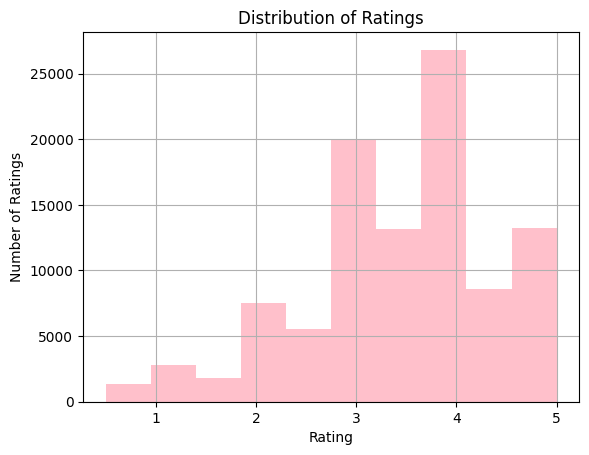

In [100]:
import matplotlib.pyplot as plt
ratings["rating"].hist(bins=10,color="pink")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Ratings")

## Most of the rated movies are given 3-4 rating by users.

In [101]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_user.head()


userId
1    232
2     29
3     39
4    216
5     44
dtype: int64

(0.0, 200.0)

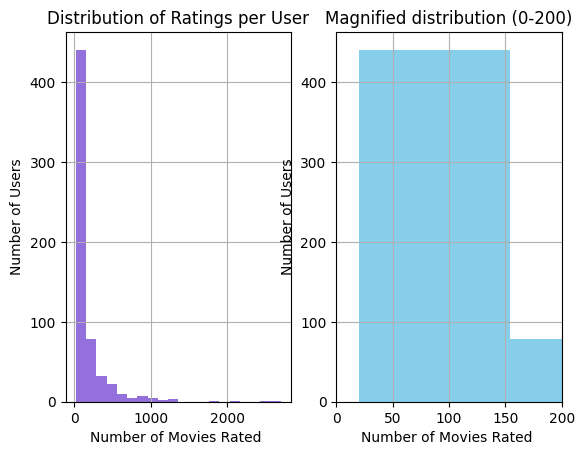

In [102]:
fig, axes = plt.subplots(1,2)
ratings_per_user.hist(bins=20,ax=axes[0],color="mediumpurple")
axes[0].set_xlabel("Number of Movies Rated ")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Distribution of Ratings per User")
ratings_per_user.hist(bins=20,ax=axes[1],color="skyblue")
axes[1].set_xlabel("Number of Movies Rated ")
axes[1].set_ylabel("Number of Users")
axes[1].set_title("Magnified distribution (0-200)")
axes[1].set_xlim(0,200)

## Based on the above output, we can conclude that most users rated(watched) around 150 movies.

In [103]:
def get_co_rated(matrix,a,b,axis):
    if axis == "index":
        x=matrix.loc[a]
        y=matrix.loc[b]
    elif axis == "columns":
        x=matrix[a]
        y=matrix[b]
    else:
        print("axis must be either 'index' or 'columns'")
    mask = x.notna() & y.notna() # -> returns a boolean vector 
    return x[mask],y[mask] # -> returns values of x and y that where mask is true 


In [104]:
import numpy as np
def euclidean_similarity(vec1, vec2):
    distance = np.sqrt(np.sum((vec1-vec2)**2))
    similarity = 1/ (1+distance)
    return similarity


## Distance vs Similarity:
with distance -> smaller means more similar 
but cosine and pearson both works with similarity where -> larger means more similar
So, just to make all metrics behave coonsistently , we will use similarity

In [105]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1,vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    similarity = dot_product / (norm1*norm2)
    return similarity


## Cosine vs Euclidean similarity
The main reason cosine similarity can be better than Euclidean similarity for user ratings is that cosine focuses on the pattern of ratings, while Euclidean focuses on the absolute difference in ratings.

for example:

A = [5, 1, 5, 1]

B = [4, 2, 4, 2]

Euclidean similarity becomes: 1/(1+2) =0.333

Cosine notices that both vectors have the same direction/pattern:
Both say:
Like Movie 1 
Dislike Movie 2 
Like Movie 3 
Dislike Movie 4 
Therefore, their vectors point in almost exactly the same direction.

The cosine similarity is approximately: 0.97 -> "Very Similar"

In [106]:
def pearson_similarity(vec1, vec2):
    mean1 = np.mean(vec1)
    mean2 = np.mean(vec2)
    centered1 = vec1 - mean1
    centered2 = vec2 - mean2

    return cosine_similarity(centered1,centered2)

## Pearson vs Cosine similarity
Pearson can be even better for user ratings because it goes one step further than cosine: it removes each user's rating bias before comparing their patterns.
Foe example

Suppose we have two users:

User A = [5, 4, 5, 3]

User B = [3, 2, 3, 1]

As we saw, they have the same pattern:

A:  HIGH → MEDIUM → HIGH → LOW

B:  HIGH → MEDIUM → HIGH → LOW

Cosine recognizes this pretty well. -> their vectors point in almost exactly the same direction.

### But notice that cosine gets the pattern using the actual ratings , while pearson will remove the rating bias of each user (mean center) first and then find their cosine similarity.
mean(A) = 4.25 ,
mean(B) = 2.25

by Subtracting : 

A: [+0.75, -0.25, +0.75, -1.25]

B: [+0.75, -0.25, +0.75, -1.25]

They're exactly the same pattern.
So Pearson = 1.0 → perfect positive correlation.


In [107]:
# Example from Section 3.2 -> 
a =np.array([5, 4, 5, 3])
b=np.array([3, 2, 3, 1])
display(euclidean_similarity(a,b))
display(cosine_similarity(a,b))
display(pearson_similarity(a,b))

np.float64(0.2)

np.float64(0.9871639953033075)

np.float64(1.0)

In [108]:
def find_k_nearest_users(matrix, target_user, k, similarity_fn):

    similarities = []
    for user in matrix.index:
        if user==target_user:
            continue
        else:
            vector1,vector2=get_co_rated(matrix,target_user,user,"index") 

        if len(vector1)<2:
            continue
        elif similarity_fn==euclidean_similarity:
            score=euclidean_similarity(vector1,vector2)
        elif similarity_fn==cosine_similarity:
            score=cosine_similarity(vector1,vector2)       
        elif similarity_fn==pearson_similarity:
            score=pearson_similarity(vector1,vector2)
        else:
            print("Please select a valid similarity function") 
            return None

        if score is None:
            continue
        similarities.append((user,score))

    similarities.sort(key=lambda x:x[1],reverse=True)
    return similarities[:k]

In [109]:
def predict_rating_user_based(matrix, target_user, target_item, k, similarity_fn):
    num=0
    den=0
    nearestk=find_k_nearest_users(matrix,target_user,k,similarity_fn)

    for userid,score in nearestk:
        if np.isnan(matrix.loc[userid,target_item]):
            continue
        else: 
            num+=score*matrix.loc[userid,target_item]
            den+=abs(score)

    if den==0:
        return None
    else:
        return num/den

In [110]:
def find_k_nearest_items(matrix, target_item, k, similarity_fn):
    similarities = []
    for item in matrix.columns:
        if item==target_item:
            continue
        else:
            vector1,vector2=get_co_rated(matrix,target_item,item,"columns") 
    
        if len(vector1)<2:
            continue
        elif similarity_fn==euclidean_similarity:
            score=euclidean_similarity(vector1,vector2)
        elif similarity_fn==cosine_similarity:
            score=cosine_similarity(vector1,vector2)       
        elif similarity_fn==pearson_similarity:
            score=pearson_similarity(vector1,vector2)
        else:
            print("Please select a valid similarity function") 
            return None
    
        if score is None:
            continue
        similarities.append((item,score))
    
    similarities.sort(key=lambda x:x[1],reverse=True)
    return similarities[:k]

In [111]:
def predict_rating_item_based(matrix, target_user, target_item, k, similarity_fn):
    num=0
    den=0
    nearestk=find_k_nearest_items(matrix,target_item,k,similarity_fn)

    for itemid,score in nearestk:
        if np.isnan(matrix.loc[target_user,itemid]):
            continue
        else: 
            num+=score*matrix.loc[target_user,itemid]
            den+=abs(score)

    if den==0:
        return None
    else:
        return num/den